<a href="https://colab.research.google.com/github/rwalden-gif/IntroToML/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay



url = 'https://raw.githubusercontent.com/rwalden-gif/IntroToML/main/diabetes.csv'
data = pd.read_csv(url)

X = data.drop(columns=["Outcome"]).values
Y = data["Outcome"].values
m = len(Y)

print(data.head())
print("Number of samples:", m)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Number of samples: 768


In [3]:
def train_logistic(X_train, y_train, X_test, y_test, epochs, penalty=None, alpha=0.0001):
    model = SGDClassifier(loss="log_loss", penalty=penalty, alpha=alpha, random_state=42)
    train_loss, test_loss, train_acc, test_acc = [], [], [], []

    for i in range(epochs):
        model.partial_fit(X_train, y_train, classes=[0, 1])
        train_loss.append(log_loss(y_train, model.predict_proba(X_train)[:, 1]))
        test_loss.append(log_loss(y_test, model.predict_proba(X_test)[:, 1]))
        train_acc.append(model.score(X_train, y_train))
        test_acc.append(model.score(X_test, y_test))

    return model, train_loss, test_loss, train_acc, test_acc

def show_results(model, X_test, y_test, labels, name):
    pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, pred):.4f}")
    print(f"Precision: {precision_score(y_test, pred):.4f}")
    print(f"Recall:    {recall_score(y_test, pred):.4f}")
    print(f"F1 score:  {f1_score(y_test, pred):.4f}")

    cm = confusion_matrix(y_test, pred)
    fig, ax = plt.subplots(figsize=(6,4.5))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues")
    plt.title(f"Confusion Matrix for {name}")
    plt.show()


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", len(Y_train))
print("Test samples:", len(Y_test))


Training samples: 614
Test samples: 154


In [5]:
epochs = 150
results_p1 = {}

model, train_loss, test_loss, train_acc, test_acc = train_logistic(X_train, Y_train, X_test, Y_test, epochs)
results_p1["Diabetes"] = (model, train_loss, test_loss, train_acc, test_acc)

print(f"Final training loss: {train_loss[-1]:.5f}")
print(f"Final test loss: {test_loss[-1]:.5f}")
print(f"Final training accuracy: {train_acc[-1]:.4f}")
print(f"Final test accuracy: {test_acc[-1]:.4f}")


Final training loss: 0.52369
Final test loss: 0.56491
Final training accuracy: 0.7638
Final test accuracy: 0.7013


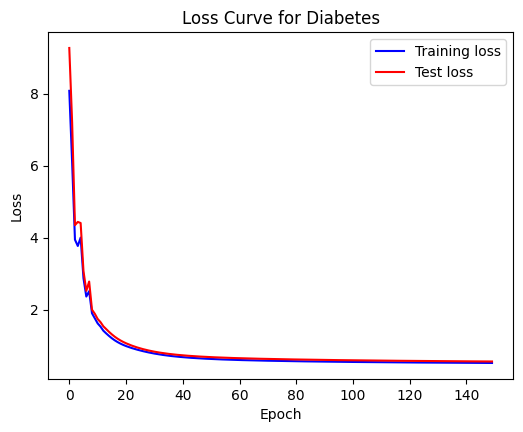

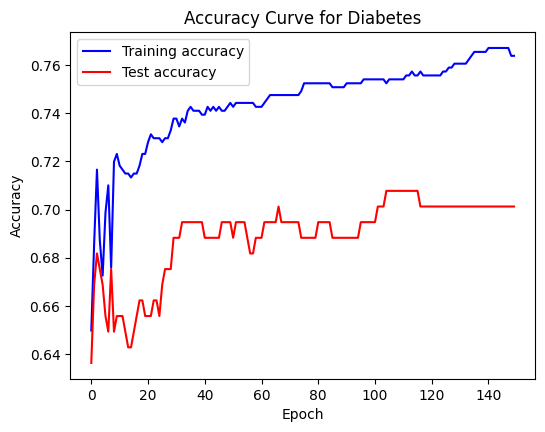

In [6]:
for name, (model, train_loss, test_loss, train_acc, test_acc) in results_p1.items():

    plt.figure(figsize=(6,4.5))
    plt.plot(train_loss, color="blue", label="Training loss")
    plt.plot(test_loss, color="red", label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve for {name}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4.5))
    plt.plot(train_acc, color="blue", label="Training accuracy")
    plt.plot(test_acc, color="red", label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curve for {name}")
    plt.legend()
    plt.show()


--- Diabetes ---
Accuracy:  0.7013
Precision: 0.5714
Recall:    0.5926
F1 score:  0.5818


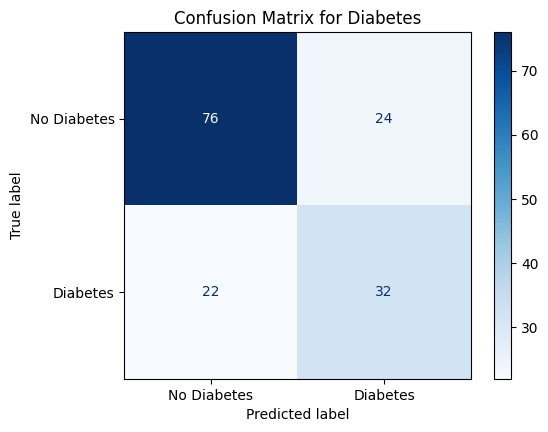

In [7]:
for name, (model, train_loss, test_loss, train_acc, test_acc) in results_p1.items():
    show_results(model, X_test, Y_test, ["No Diabetes", "Diabetes"], name)

In [8]:
url = 'https://raw.githubusercontent.com/rwalden-gif/IntroToML/main/Cancer.csv'
cancer = pd.read_csv(url)
cancer = cancer.drop(columns=["Unnamed: 32", "id"])

Xc = cancer.drop(columns=["diagnosis"]).values
Yc = (cancer["diagnosis"] == "M").astype(int).values

print(cancer.head())
print("Number of samples:", len(Yc))
print("Number of features:", Xc.shape[1])

Xc_train, Xc_test, Yc_train, Yc_test = train_test_split(Xc, Yc, test_size=0.2, random_state=42, stratify=Yc)

scaler_c = StandardScaler()
Xc_train = scaler_c.fit_transform(Xc_train)
Xc_test = scaler_c.transform(Xc_test)

print("Training samples:", len(Yc_train))
print("Test samples:", len(Yc_test))


  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          17.33 

In [9]:
results_p2 = {}

model, train_loss, test_loss, train_acc, test_acc = train_logistic(Xc_train, Yc_train, Xc_test, Yc_test, epochs)
results_p2["No Penalty"] = (model, train_loss, test_loss, train_acc, test_acc)

print(f"Final training loss: {train_loss[-1]:.5f}")
print(f"Final test loss: {test_loss[-1]:.5f}")
print(f"Final training accuracy: {train_acc[-1]:.4f}")
print(f"Final test accuracy: {test_acc[-1]:.4f}")


Final training loss: 0.02351
Final test loss: 1.26498
Final training accuracy: 0.9978
Final test accuracy: 0.9649


In [10]:
penalty_strengths = [0.0001, 0.001, 0.01, 0.1]
best_alpha, best_result = None, None

for alpha in penalty_strengths:
    model, train_loss, test_loss, train_acc, test_acc = train_logistic(Xc_train, Yc_train, Xc_test, Yc_test, epochs, penalty="l2", alpha=alpha)
    print(f"alpha={alpha} -> final test loss={test_loss[-1]:.5f}, final test accuracy={test_acc[-1]:.4f}")

    if best_result is None or test_loss[-1] < best_result[2][-1]:
        best_alpha, best_result = alpha, (model, train_loss, test_loss, train_acc, test_acc)

results_p2["With Penalty"] = best_result
print(f">> Best penalty strength: alpha={best_alpha}")


alpha=0.0001 -> final test loss=0.18867, final test accuracy=0.9649
alpha=0.001 -> final test loss=0.08851, final test accuracy=0.9737
alpha=0.01 -> final test loss=0.08103, final test accuracy=0.9825
alpha=0.1 -> final test loss=0.14298, final test accuracy=0.9561
>> Best penalty strength: alpha=0.01


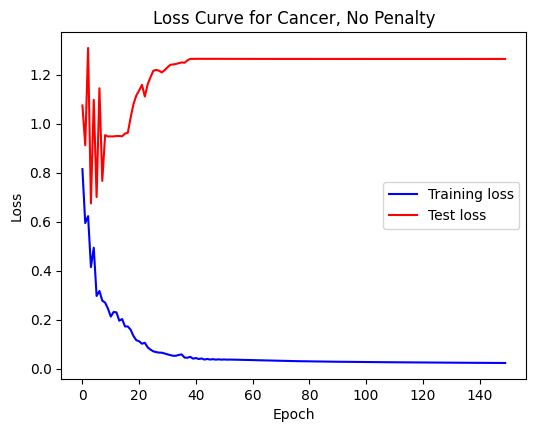

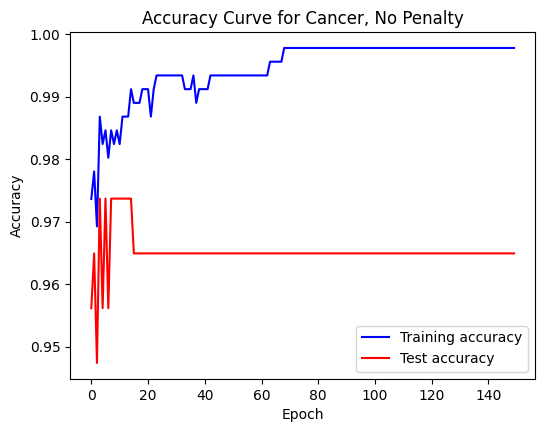

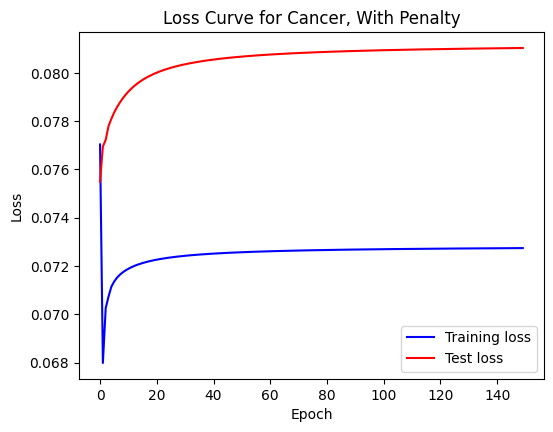

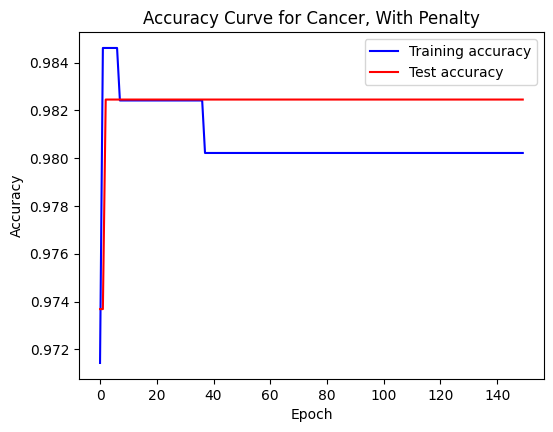

In [11]:
for name, (model, train_loss, test_loss, train_acc, test_acc) in results_p2.items():

    plt.figure(figsize=(6,4.5))
    plt.plot(train_loss, color="blue", label="Training loss")
    plt.plot(test_loss, color="red", label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curve for Cancer, {name}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4.5))
    plt.plot(train_acc, color="blue", label="Training accuracy")
    plt.plot(test_acc, color="red", label="Test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Curve for Cancer, {name}")
    plt.legend()
    plt.show()


--- Cancer, No Penalty ---
Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
F1 score:  0.9512


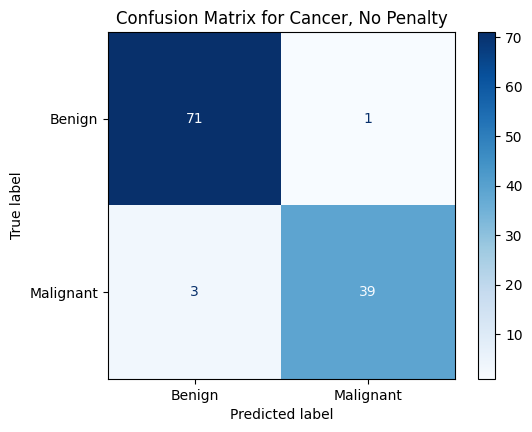

--- Cancer, With Penalty ---
Accuracy:  0.9825
Precision: 1.0000
Recall:    0.9524
F1 score:  0.9756


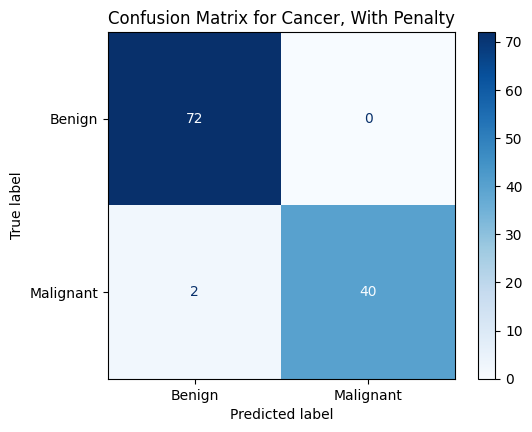

Diabetes: F1 score = 0.5818
Cancer, No Penalty: F1 score = 0.9512
Cancer, With Penalty: F1 score = 0.9756


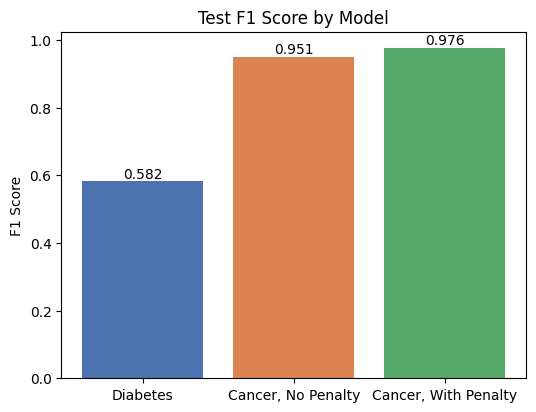

In [12]:
for name, (model, train_loss, test_loss, train_acc, test_acc) in results_p2.items():
    show_results(model, Xc_test, Yc_test, ["Benign", "Malignant"], "Cancer, " + name)

final_f1 = {}
final_f1["Diabetes"] = f1_score(Y_test, results_p1["Diabetes"][0].predict(X_test))
final_f1["Cancer, No Penalty"] = f1_score(Yc_test, results_p2["No Penalty"][0].predict(Xc_test))
final_f1["Cancer, With Penalty"] = f1_score(Yc_test, results_p2["With Penalty"][0].predict(Xc_test))

for k, v in final_f1.items():
    print(f"{k}: F1 score = {v:.4f}")

plt.figure(figsize=(6,4.5))
plt.bar(final_f1.keys(), final_f1.values(), color=["#4C72B0","#DD8452","#55A868"])
plt.ylabel("F1 Score")
plt.title("Test F1 Score by Model")
for i, (k, v) in enumerate(final_f1.items()):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center")
plt.show()
